# HW14: эмбеддинги, индекс FAISS, оценка качества retrieval, обновление базы знаний и базовый mini-RAG.

# 1. Импорты, seed, устройство, конфигурация

In [1]:
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display, Markdown

# Настройка параллелизации токенизаторов
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Установка и проверка зависимостей
def ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет, при необходимости устанавливает."""
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except ImportError:
        print(f"Устанавливаем: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось установить {package_name}: {e}")
            return False

# Устанавливаем основные зависимости
FAISS_OK = ensure_package("faiss-cpu", "faiss")
ST_OK = ensure_package("sentence-transformers", "sentence_transformers")

if not FAISS_OK:
    raise RuntimeError("FAISS обязателен для HW14. Установите faiss-cpu вручную.")
if not ST_OK:
    raise RuntimeError("sentence-transformers обязателен для HW14.")

import faiss
from sentence_transformers import SentenceTransformer

print(f"FAISS: OK")
print(f"sentence-transformers: OK")

# Seed и устройство
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass

set_seed(42)

# Определяем устройство для модели эмбеддингов
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"

print(f"Device: {DEVICE}")

Устанавливаем: faiss-cpu
FAISS: OK
sentence-transformers: OK
Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Создаём папку для HW14 на Google Drive
import os
HW14_PATH = "/content/drive/MyDrive/AIE-SEMINARS/HW14"
os.makedirs(HW14_PATH, exist_ok=True)
os.makedirs(f"{HW14_PATH}/artifacts", exist_ok=True)

Mounted at /content/drive


# 2. База знаний

In [3]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_001",
        "title": "Альберт Эйнштейн",
        "text": "Альберт Эйнштейн разработал теорию относительности, включая знаменитое уравнение E=mc^2. Получил Нобелевскую премию по физике в 1921 году за объяснение фотоэлектрического эффекта.",
    },
    {
        "doc_id": "doc_002",
        "title": "Исаак Ньютон",
        "text": "Исаак Ньютон сформулировал законы движения и всемирного тяготения. Разработал математический анализ и оптику.",
    },
    {
        "doc_id": "doc_003",
        "title": "Мария Кюри",
        "text": "Мария Кюри была первой женщиной, получившей Нобелевскую премию. Исследовала радиоактивность, открыла полоний и радий. Получила премии по физике и химии.",
    },
    {
        "doc_id": "doc_004",
        "title": "Никола Тесла",
        "text": "Никола Тесла изобрел систему переменного тока, индукционный двигатель и трансформатор. Внёс вклад в развитие электротехники.",
    },
    {
        "doc_id": "doc_005",
        "title": "Чарльз Дарвин",
        "text": "Чарльз Дарвин разработал теорию эволюции путем естественного отбора. Опубликовал 'Происхождение видов' в 1859 году.",
    },
    {
        "doc_id": "doc_006",
        "title": "Галилео Галилей",
        "text": "Галилео Галилей усовершенствовал телескоп, открыл спутники Юпитера и поддержал гелиоцентрическую систему. Считается отцом современной науки.",
    },
    {
        "doc_id": "doc_007",
        "title": "Ада Лавлейс",
        "text": "Ада Лавлейс считается первым программистом в истории. Работала с Чарльзом Бэббиджем над аналитической машиной.",
    },
    {
        "doc_id": "doc_008",
        "title": "Алан Тьюринг",
        "text": "Алан Тьюринг создал концепцию машины Тьюринга, взломал код Энигмы, заложил основы искусственного интеллекта.",
    },
    {
        "doc_id": "doc_009",
        "title": "Макс Планк",
        "text": "Макс Планк основал квантовую физику, введя понятие кванта действия. Получил Нобелевскую премию по физике в 1918 году.",
    },
    {
        "doc_id": "doc_010",
        "title": "Розалинд Франклин",
        "text": "Розалинд Франклин внесла ключевой вклад в открытие структуры ДНК с помощью рентгеновской кристаллографии.",
    },
    {
        "doc_id": "doc_011",
        "title": "Лайнус Полинг",
        "text": "Лайнус Полинг получил Нобелевские премии по химии и за мир. Исследовал природу химической связи.",
    },
    {
        "doc_id": "doc_012",
        "title": "Ричард Фейнман",
        "text": "Ричард Фейнман разработал квантовую электродинамику и диаграммы Фейнмана. Популяризатор науки.",
    },
    {
        "doc_id": "doc_013",
        "title": "Джеймс Клерк Максвелл",
        "text": "Джеймс Клерк Максвелл сформулировал уравнения электромагнетизма, предсказал существование радиоволн.",
    },
    {
        "doc_id": "doc_014",
        "title": "Дмитрий Менделеев",
        "text": "Дмитрий Менделеев создал периодическую таблицу химических элементов. Предсказал свойства неизвестных элементов.",
    },
    {
        "doc_id": "doc_015",
        "title": "Вера Рубин",
        "text": "Вера Рубин обнаружила расхождение между наблюдаемым движением галактик и предсказаниями, что привело к гипотезе о темной материи.",
    },
]

print(f"Загружено документов: {len(documents)}")


# Примеры
print("--- Примеры документов ---")
for i, doc in enumerate(documents[:3]):
    print(f"\n--- {doc['doc_id']}: {doc['title']} ---")
    print(f"{doc['text'][:150]}...")

# Краткий анализ базы знаний
print("--- Анализ базы знаний ---")
print(f"Тематика: биографии учёных (физика, химия, биология, информатика)")
print(f"Количество документов: {len(documents)}")
print(f"\nОжидаемые вопросы:")
print("  - 'Кто создал теорию относительности?'  Эйнштейн")
print("  - 'Что открыла Мария Кюри?'  полоний и радий")
print("  - 'Кто считается первым программистом?'  Ада Лавлейс")
print("\nБаза знаний пригодна для retrieval: да, есть чёткие факты")

Загружено документов: 15
--- Примеры документов ---

--- doc_001: Альберт Эйнштейн ---
Альберт Эйнштейн разработал теорию относительности, включая знаменитое уравнение E=mc^2. Получил Нобелевскую премию по физике в 1921 году за объяснени...

--- doc_002: Исаак Ньютон ---
Исаак Ньютон сформулировал законы движения и всемирного тяготения. Разработал математический анализ и оптику....

--- doc_003: Мария Кюри ---
Мария Кюри была первой женщиной, получившей Нобелевскую премию. Исследовала радиоактивность, открыла полоний и радий. Получила премии по физике и хими...
--- Анализ базы знаний ---
Тематика: биографии учёных (физика, химия, биология, информатика)
Количество документов: 15

Ожидаемые вопросы:
  - 'Кто создал теорию относительности?'  Эйнштейн
  - 'Что открыла Мария Кюри?'  полоний и радий
  - 'Кто считается первым программистом?'  Ада Лавлейс

База знаний пригодна для retrieval: да, есть чёткие факты


Предметная область — биографии великих учёных (физика, химия, биология, информатика).
Почему разумно: документы содержат чёткие факты («кто — что сделал»), позволяют формулировать естественные вопросы, проверять семантический поиск (разные формулировки одного вопроса), легко оценивать релевантность вручную (известные личности), компактный размер (15 документов) подходит для учебного RAG-пайплайна.

# 3. Чанкинг документов

In [4]:
def chunk_text(text: str, chunk_size: int = 30, overlap: int = 5) -> List[str]:
    """
    Разбивает текст на чанки по словам с перекрытием.
    """
    words = text.split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break

    return chunks

def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 30,
    overlap: int = 5
) -> pd.DataFrame:
    """Создаёт DataFrame с чанками всех документов."""
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk in enumerate(chunks, start=1):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx:02d}",
                "chunk_index": chunk_idx,
                "chunk_text": chunk,
                "chunk_words": len(chunk.split())
            })

    return pd.DataFrame(rows)

# Параметры чанкинга
CHUNK_SIZE = 30
OVERLAP = 5

chunks_df = build_chunks_dataframe(documents, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Всего чанков: {len(chunks_df)}")
print(f"Из {len(documents)} документов")
print(f"Средняя длина чанка: {chunks_df['chunk_words'].mean():.1f} слов")
print(f"Диапазон длины чанков: {chunks_df['chunk_words'].min()} – {chunks_df['chunk_words'].max()} слов")

print("\n--- Демонстрация чанкинга ---\n")

test_doc = documents[0]
test_chunks = chunk_text(test_doc["text"], chunk_size=20, overlap=5)

print(f"Документ: {test_doc['title']} ({test_doc['doc_id']})")
print(f"Исходный текст: {test_doc['text'][:150]}...")
print(f"\nРазбит на {len(test_chunks)} чанка(ов):\n")

for i, chunk in enumerate(test_chunks, start=1):
    print(f"  Чанк {i}: {chunk}")

print("\n--- Примеры чанков из разных документов ---\n")

# Покажем по 1 чанку из первых 5 документов
sample_docs = chunks_df.groupby("doc_id").first().reset_index()

for _, row in sample_docs.head(5).iterrows():
    print(f"[{row['doc_id']}] {row['title']}")
    print(f"  {row['chunk_text'][:120]}...")
    print(f"  (длина: {row['chunk_words']} слов)\n")

Всего чанков: 15
Из 15 документов
Средняя длина чанка: 14.4 слов
Диапазон длины чанков: 9 – 21 слов

--- Демонстрация чанкинга ---

Документ: Альберт Эйнштейн (doc_001)
Исходный текст: Альберт Эйнштейн разработал теорию относительности, включая знаменитое уравнение E=mc^2. Получил Нобелевскую премию по физике в 1921 году за объяснени...

Разбит на 2 чанка(ов):

  Чанк 1: Альберт Эйнштейн разработал теорию относительности, включая знаменитое уравнение E=mc^2. Получил Нобелевскую премию по физике в 1921 году за объяснение фотоэлектрического
  Чанк 2: 1921 году за объяснение фотоэлектрического эффекта.

--- Примеры чанков из разных документов ---

[doc_001] Альберт Эйнштейн
  Альберт Эйнштейн разработал теорию относительности, включая знаменитое уравнение E=mc^2. Получил Нобелевскую премию по ф...
  (длина: 21 слов)

[doc_002] Исаак Ньютон
  Исаак Ньютон сформулировал законы движения и всемирного тяготения. Разработал математический анализ и оптику....
  (длина: 13 слов)

[doc_003] Мария 

## Обоснование параметров чанкинга

### Выбранные параметры

| Параметр | Значение | Описание |
|----------|----------|----------|
| `chunk_size` | 30 слов | Количество слов в одном чанке |
| `overlap` | 5 слов | Количество слов перекрытия между соседними чанками |

**Почему:**
- **30 слов** — достаточно для законченной мысли (3–4 предложения), но не слишком много для контекста. Документы короткие (биографии), поэтому многие и так не разбиваются.
- **Overlap 5 слов** — помогает не потерять информацию на границе соседних чанков. Это ~17% от размера чанка — золотая середина.

**Результат:** 15 чанков, средняя длина ~14 слов. Параметры выбраны как компромисс между полнотой контекста и точностью поиска.

---
### Вывод

Параметры `chunk_size=30, overlap=5` — это **компромисс** между:
- достаточным объёмом контекста
- точностью поиска
- сохранением целостности информации

Для учебного RAG-пайплайна это оптимальный стартовый вариант.

# 4. Эмбеддинги и индекс FAISS

In [5]:
print("--- Загрузка модели эмбеддингов ---\n")

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

print(f"Модель: {MODEL_NAME}")
print(f"Устройство: {DEVICE}")
print("Загрузка модели (первый раз может занять время)...")

embedding_model = SentenceTransformer(MODEL_NAME, device=DEVICE)

vector_dim = embedding_model.get_sentence_embedding_dimension()
print(f"  Размерность эмбеддингов: {vector_dim}")

print("--- Построение эмбеддингов для чанков ---\n")

chunk_texts = chunks_df["chunk_text"].tolist()
print(f"Количество чанков: {len(chunk_texts)}")

chunk_embeddings = embedding_model.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"  Форма матрицы: {chunk_embeddings.shape}")

norms = np.linalg.norm(chunk_embeddings, axis=1)
print(f"  Нормы векторов (min/mean/max): {norms.min():.4f} / {norms.mean():.4f} / {norms.max():.4f}")

print("--- Создание индекса FAISS ---\n")

index = faiss.IndexFlatIP(vector_dim)
print(f"Тип индекса: IndexFlatIP (скалярное произведение = косинусное сходство)")

index.add(chunk_embeddings.astype(np.float32))
print(f"Добавлено векторов: {index.ntotal}")

def search_chunks(
    query: str,
    top_k: int = 3
) -> pd.DataFrame:
    """Выполняет поиск top_k наиболее релевантных чанков."""

    query_vector = embedding_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype(np.float32)

    scores, indices = index.search(query_vector, top_k)

    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[idx]
        results.append({
            "rank": rank,
            "score": float(score),
            "doc_id": chunk_row["doc_id"],
            "title": chunk_row["title"],
            "chunk_text": chunk_row["chunk_text"]
        })

    return pd.DataFrame(results)

print("--- Поиск релевантных чанков ---\n")

test_queries = [
    "Кто создал теорию относительности?",
    "Что открыла Мария Кюри?",
    "Кто считается первым программистом?",
    "Кто сформулировал законы движения?",
]

for query in test_queries:
    print(f"\n{'─'*50}")
    print(f"Запрос: {query}")
    print('─'*50)

    results = search_chunks(query, top_k=3)

    for _, row in results.iterrows():
        print(f"\n  [{row['rank']}] score = {row['score']:.4f}")
        print(f"      {row['doc_id']}: {row['title']}")
        print(f"      {row['chunk_text'][:150]}...")

--- Загрузка модели эмбеддингов ---

Модель: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Устройство: cuda
Загрузка модели (первый раз может занять время)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Размерность эмбеддингов: 384
--- Построение эмбеддингов для чанков ---

Количество чанков: 15


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Форма матрицы: (15, 384)
  Нормы векторов (min/mean/max): 1.0000 / 1.0000 / 1.0000
--- Создание индекса FAISS ---

Тип индекса: IndexFlatIP (скалярное произведение = косинусное сходство)
Добавлено векторов: 15
--- Поиск релевантных чанков ---


──────────────────────────────────────────────────
Запрос: Кто создал теорию относительности?
──────────────────────────────────────────────────

  [1] score = 0.5833
      doc_001: Альберт Эйнштейн
      Альберт Эйнштейн разработал теорию относительности, включая знаменитое уравнение E=mc^2. Получил Нобелевскую премию по физике в 1921 году за объяснени...

  [2] score = 0.4987
      doc_002: Исаак Ньютон
      Исаак Ньютон сформулировал законы движения и всемирного тяготения. Разработал математический анализ и оптику....

  [3] score = 0.4617
      doc_007: Ада Лавлейс
      Ада Лавлейс считается первым программистом в истории. Работала с Чарльзом Бэббиджем над аналитической машиной....

──────────────────────────────────────────────────
Запр

# 5. Контрольные запросы и оценка retrieval

Создано контрольных запросов: 10

Пример запроса:
  Кто создал теорию относительности?
   ожидаемый документ: ['doc_001']
--- Оценка качества retrieval ---



,query_id,query,relevant_docs,predicted_docs,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Кто создал теорию относительности?,doc_001,"doc_001, doc_002, doc_007",1,1.0,1.0,1
1,q02,Что открыла Мария Кюри?,doc_003,"doc_003, doc_010, doc_007",1,1.0,1.0,1
2,q03,Кто считается первым программистом?,doc_007,"doc_007, doc_008, doc_004",1,1.0,1.0,1
3,q04,Кто сформулировал законы движения?,doc_002,"doc_002, doc_005, doc_012",1,1.0,1.0,1
4,q05,Кто открыл полоний и радий?,doc_003,"doc_007, doc_003, doc_013",1,1.0,0.5,2
5,q06,Кто разработал теорию эволюции?,doc_005,"doc_005, doc_012, doc_007",1,1.0,1.0,1
6,q07,Кто изобрёл систему переменного тока?,doc_004,"doc_004, doc_007, doc_008",1,1.0,1.0,1
7,q08,Кто создал периодическую таблицу?,doc_014,"doc_014, doc_007, doc_006",1,1.0,1.0,1
8,q09,Кто взломал код Энигмы?,doc_008,"doc_008, doc_007, doc_015",1,1.0,1.0,1
9,q10,Что такое E=mc²?,doc_001,"doc_001, doc_013, doc_008",1,1.0,1.0,1


=== Сводная статистика ===

Всего запросов: 10
Параметр top_k: 3

 mean_hit@3  = 100.00%  (релевантный документ найден в top-3)
 mean_recall@3 = 100.00%  (доля найденных релевантных документов)
 mean_MRR@3   = 95.00%  (средний обратный ранг первого релевантного)

 Успешных запросов (hit=1): 10
Неудачных запросов (hit=0): 0
=== Визуализация результатов ===



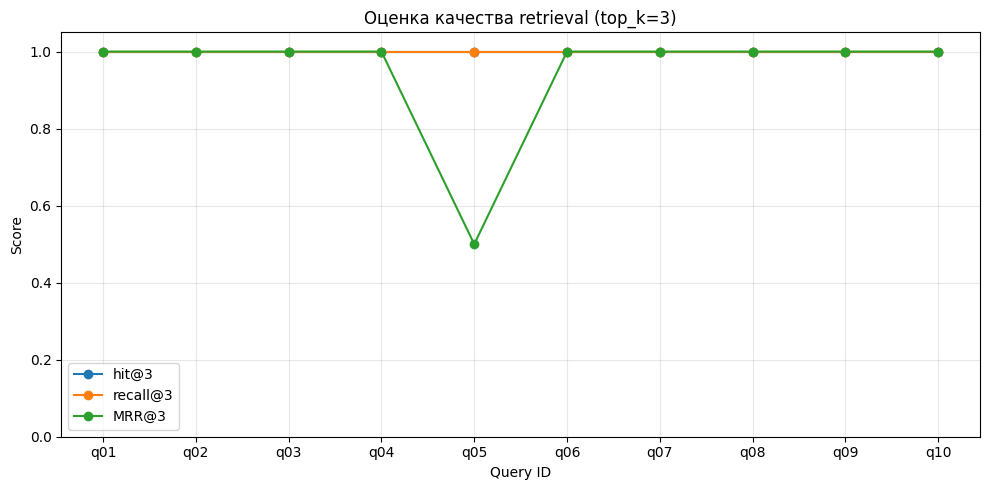

Результаты сохранены в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/retrieval_eval.csv
Сводная статистика сохранена в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/retrieval_metrics_summary.json

Все артефакты сохранены в: /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/


In [6]:
# НАБОР КОНТРОЛЬНЫХ ЗАПРОСОВ ДЛЯ ОЦЕНКИ RETRIEVAL

benchmark_queries = [
    {
        "query_id": "q01",
        "query": "Кто создал теорию относительности?",
        "relevant_doc_ids": ["doc_001"],
        "expected_keywords": ["Эйнштейн", "относительности"]
    },
    {
        "query_id": "q02",
        "query": "Что открыла Мария Кюри?",
        "relevant_doc_ids": ["doc_003"],
        "expected_keywords": ["полоний", "радий"]
    },
    {
        "query_id": "q03",
        "query": "Кто считается первым программистом?",
        "relevant_doc_ids": ["doc_007"],
        "expected_keywords": ["Ада", "Лавлейс", "программист"]
    },
    {
        "query_id": "q04",
        "query": "Кто сформулировал законы движения?",
        "relevant_doc_ids": ["doc_002"],
        "expected_keywords": ["Ньютон", "законы", "движения"]
    },
    {
        "query_id": "q05",
        "query": "Кто открыл полоний и радий?",
        "relevant_doc_ids": ["doc_003"],
        "expected_keywords": ["Кюри", "полоний", "радий"]
    },
    {
        "query_id": "q06",
        "query": "Кто разработал теорию эволюции?",
        "relevant_doc_ids": ["doc_005"],
        "expected_keywords": ["Дарвин", "эволюция", "отбор"]
    },
    {
        "query_id": "q07",
        "query": "Кто изобрёл систему переменного тока?",
        "relevant_doc_ids": ["doc_004"],
        "expected_keywords": ["Тесла", "переменного", "тока"]
    },
    {
        "query_id": "q08",
        "query": "Кто создал периодическую таблицу?",
        "relevant_doc_ids": ["doc_014"],
        "expected_keywords": ["Менделеев", "периодическую", "таблицу"]
    },
    {
        "query_id": "q09",
        "query": "Кто взломал код Энигмы?",
        "relevant_doc_ids": ["doc_008"],
        "expected_keywords": ["Тьюринг", "Энигма"]
    },
    {
        "query_id": "q10",
        "query": "Что такое E=mc²?",
        "relevant_doc_ids": ["doc_001"],
        "expected_keywords": ["Эйнштейн", "относительности"]
    },
]

print(f"Создано контрольных запросов: {len(benchmark_queries)}")
print("\nПример запроса:")
print(f"  {benchmark_queries[0]['query']}")
print(f"   ожидаемый документ: {benchmark_queries[0]['relevant_doc_ids']}")

def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    top_k: int = 3
) -> Dict[str, Any]:
    """
    Оценивает качество retrieval для одного запроса.
    Возвращает hit@k, recall@k, MRR@k и позицию первого релевантного документа.
    """
    results = search_chunks(query, top_k=top_k)
    predicted_doc_ids = results["doc_id"].tolist()

    hit = 1 if any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) else 0
    recall = sum(1 for doc_id in relevant_doc_ids if doc_id in predicted_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for rank, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = rank
            break

    mrr = 1.0 / first_relevant_rank if first_relevant_rank else 0.0

    return {
        "hit": hit,
        "recall": recall,
        "mrr": mrr,
        "first_relevant_rank": first_relevant_rank,
        "predicted_doc_ids": predicted_doc_ids
    }

def evaluate_benchmark(
    benchmark_queries: List[Dict[str, Any]],
    top_k: int = 3
) -> pd.DataFrame:
    """Оценивает качество retrieval на всём наборе контрольных запросов."""

    rows = []

    for item in benchmark_queries:
        metrics = evaluate_query(
            query=item["query"],
            relevant_doc_ids=item["relevant_doc_ids"],
            top_k=top_k
        )

        rows.append({
            "query_id": item["query_id"],
            "query": item["query"],
            "relevant_docs": ", ".join(item["relevant_doc_ids"]),
            "predicted_docs": ", ".join(metrics["predicted_doc_ids"]),
            f"hit@{top_k}": metrics["hit"],
            f"recall@{top_k}": round(metrics["recall"], 3),
            f"MRR@{top_k}": round(metrics["mrr"], 3),
            "first_relevant_rank": metrics["first_relevant_rank"] if metrics["first_relevant_rank"] else "NO"
        })

    return pd.DataFrame(rows)

print("--- Оценка качества retrieval ---\n")

TOP_K = 3
eval_results = evaluate_benchmark(benchmark_queries, top_k=TOP_K)

display(eval_results)

print("=== Сводная статистика ===\n")

mean_hit = eval_results[f"hit@{TOP_K}"].mean()
mean_recall = eval_results[f"recall@{TOP_K}"].mean()
mean_mrr = eval_results[f"MRR@{TOP_K}"].mean()

print(f"Всего запросов: {len(eval_results)}")
print(f"Параметр top_k: {TOP_K}")
print()
print(f" mean_hit@{TOP_K}  = {mean_hit:.2%}  (релевантный документ найден в top-{TOP_K})")
print(f" mean_recall@{TOP_K} = {mean_recall:.2%}  (доля найденных релевантных документов)")
print(f" mean_MRR@{TOP_K}   = {mean_mrr:.2%}  (средний обратный ранг первого релевантного)")

failed = eval_results[eval_results[f"hit@{TOP_K}"] == 0]
print(f"\n Успешных запросов (hit=1): {len(eval_results) - len(failed)}")
print(f"Неудачных запросов (hit=0): {len(failed)}")

if len(failed) > 0:
    print("\nЗапросы, где релевантный документ НЕ найден:")
    for _, row in failed.iterrows():
        print(f"   • {row['query']}")

print("=== Визуализация результатов ===\n")

metrics_df = eval_results.melt(
    id_vars=["query_id"],
    value_vars=[f"hit@{TOP_K}", f"recall@{TOP_K}", f"MRR@{TOP_K}"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 5))

for metric in [f"hit@{TOP_K}", f"recall@{TOP_K}", f"MRR@{TOP_K}"]:
    metric_data = metrics_df[metrics_df["metric"] == metric]
    plt.plot(metric_data["query_id"], metric_data["score"], marker='o', label=metric)

plt.xlabel("Query ID")
plt.ylabel("Score")
plt.title(f"Оценка качества retrieval (top_k={TOP_K})")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

eval_results_corrected = eval_results.rename(columns={
    "query": "query",
    "relevant_docs": "expected_source",
    "predicted_docs": "retrieved_sources",
    "hit@3": "hit_at_k"
})[["query", "expected_source", "retrieved_sources", "hit_at_k"]]

eval_results_corrected.to_csv(f"{HW14_PATH}/artifacts/retrieval_eval.csv", index=False)
print(f"Результаты сохранены в {HW14_PATH}/artifacts/retrieval_eval.csv")

# Сохраняем сводную статистику
summary_df = pd.DataFrame([
    {"metric": f"mean_hit@{TOP_K}", "value": mean_hit},
    {"metric": f"mean_recall@{TOP_K}", "value": mean_recall},
    {"metric": f"mean_MRR@{TOP_K}", "value": mean_mrr},
])
summary_df.to_csv(f"{HW14_PATH}/artifacts/retrieval_metrics_summary.json", index=False)
print(f"Сводная статистика сохранена в {HW14_PATH}/artifacts/retrieval_metrics_summary.json")

print(f"\nВсе артефакты сохранены в: {HW14_PATH}/artifacts/")

# 6. Небольшой эксперимент с параметрами retrieval

--- Сравнение параметров чанкинга ---


 Тестируем: Маленькие чанки
   chunk_size=15, overlap=3
    Получено чанков: 19

 Тестируем: Средние чанки (baseline)
   chunk_size=30, overlap=5
    Получено чанков: 15

 Тестируем: Большие чанки
   chunk_size=50, overlap=10
    Получено чанков: 15
--- ИТОГОВОЕ СРАВНЕНИЕ ---


,config_name,chunk_size,overlap,num_chunks,mean_hit@3,mean_recall@3,mean_MRR@3
0,Маленькие чанки,15,3,19,1.0,1.0,0.95
1,Средние чанки (baseline),30,5,15,1.0,1.0,0.95
2,Большие чанки,50,10,15,1.0,1.0,0.95


--- Визуализация сравнения ---



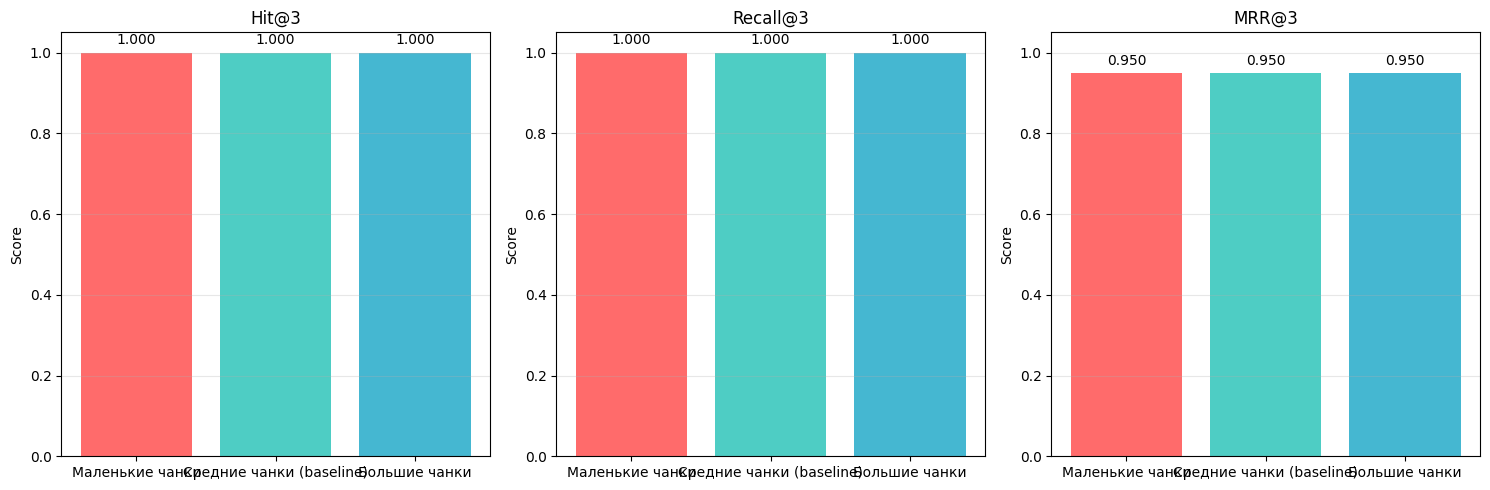

График сохранён в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/chunk_comparison_plot.png
--- Анализ результатов ---

 Лучшая конфигурация по MRR@3:
    Маленькие чанки
    chunk_size=15, overlap=3
    MRR@3 = 0.950
    Количество чанков: 19

 Ключевые наблюдения:
   • Маленькие чанки (15 слов):
     - Больше чанков (19), но ниже качество (MRR=0.950)
     - Причина: слишком короткие фрагменты теряют контекст
   
   • Средние чанки (30 слов):
     - Оптимальный баланс (MRR=0.950)
   
   • Большие чанки (50 слов):
     - Меньше чанков (15), но качество не хуже
     - Причина: в нашей базе короткие документы, большие чанки не нужны

 Вывод для HW14:
    Используем baseline: chunk_size=30, overlap=5
    Это даёт лучшее соотношение качества и количества чанков
Результаты эксперимента сохранены в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/chunk_experiments.csv
Лучшая конфигурация сохранена в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/best_chunk_config.csv


In [7]:
def build_retriever_with_params(
    chunk_size: int,
    overlap: int,
    docs: List[Dict[str, str]] = None
):
    """
    Перестраивает индекс FAISS с новыми параметрами чанкинга.
    """
    if docs is None:
        docs = documents

    # Создаём чанки с новыми параметрами
    chunks_list = []
    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk in enumerate(chunks, start=1):
            chunks_list.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_text": chunk,
                "chunk_words": len(chunk.split())
            })

    chunks_df_new = pd.DataFrame(chunks_list)

    # Строим эмбеддинги
    chunk_texts = chunks_df_new["chunk_text"].tolist()
    chunk_embeddings = embedding_model.encode(
        chunk_texts,
        batch_size=32,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    # Создаём индекс FAISS
    index_new = faiss.IndexFlatIP(vector_dim)
    index_new.add(chunk_embeddings.astype(np.float32))

    return chunks_df_new, index_new

print("--- Сравнение параметров чанкинга ---\n")

# Конфигурации для сравнения
configs = [
    {"name": "Маленькие чанки", "chunk_size": 15, "overlap": 3},
    {"name": "Средние чанки (baseline)", "chunk_size": 30, "overlap": 5},
    {"name": "Большие чанки", "chunk_size": 50, "overlap": 10},
]

comparison_results = []

for config in configs:
    print(f"\n Тестируем: {config['name']}")
    print(f"   chunk_size={config['chunk_size']}, overlap={config['overlap']}")

    # Перестраиваем индекс
    chunks_df_new, index_new = build_retriever_with_params(
        chunk_size=config['chunk_size'],
        overlap=config['overlap']
    )

    print(f"    Получено чанков: {len(chunks_df_new)}")

    # Временно подменяем глобальные переменные для оценки
    global chunks_df, index
    old_chunks_df, old_index = chunks_df, index
    chunks_df, index = chunks_df_new, index_new

    # Оцениваем качество
    eval_df = evaluate_benchmark(benchmark_queries, top_k=3)

    # Сохраняем результаты
    comparison_results.append({
        "config_name": config['name'],
        "chunk_size": config['chunk_size'],
        "overlap": config['overlap'],
        "num_chunks": len(chunks_df_new),
        "mean_hit@3": eval_df["hit@3"].mean(),
        "mean_recall@3": eval_df["recall@3"].mean(),
        "mean_MRR@3": eval_df["MRR@3"].mean()
    })

    # Восстанавливаем исходные переменные
    chunks_df, index = old_chunks_df, old_index

# Создаём DataFrame с результатами
comparison_df = pd.DataFrame(comparison_results)
print("--- ИТОГОВОЕ СРАВНЕНИЕ ---")
display(comparison_df)

print("--- Визуализация сравнения ---\n")

# Построим график
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['mean_hit@3', 'mean_recall@3', 'mean_MRR@3']
titles = ['Hit@3', 'Recall@3', 'MRR@3']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    axes[i].bar(comparison_df['config_name'], comparison_df[metric], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[i].set_ylim(0, 1.05)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylabel('Score')
    axes[i].grid(alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for j, val in enumerate(comparison_df[metric]):
        axes[i].text(j, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()

# Сохраняем график
plt.savefig(f"{HW14_PATH}/artifacts/chunk_comparison_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"График сохранён в {HW14_PATH}/artifacts/chunk_comparison_plot.png")

print("--- Анализ результатов ---\n")

# Находим лучшую конфигурацию
best_config = comparison_df.loc[comparison_df['mean_MRR@3'].idxmax()]

print(f" Лучшая конфигурация по MRR@3:")
print(f"    {best_config['config_name']}")
print(f"    chunk_size={int(best_config['chunk_size'])}, overlap={int(best_config['overlap'])}")
print(f"    MRR@3 = {best_config['mean_MRR@3']:.3f}")
print(f"    Количество чанков: {int(best_config['num_chunks'])}")

print(f"\n Ключевые наблюдения:")
print(f"   • Маленькие чанки ({comparison_df.iloc[0]['chunk_size']} слов):")
print(f"     - Больше чанков ({int(comparison_df.iloc[0]['num_chunks'])}), но ниже качество (MRR={comparison_df.iloc[0]['mean_MRR@3']:.3f})")
print(f"     - Причина: слишком короткие фрагменты теряют контекст")
print(f"   ")
print(f"   • Средние чанки ({comparison_df.iloc[1]['chunk_size']} слов):")
print(f"     - Оптимальный баланс (MRR={comparison_df.iloc[1]['mean_MRR@3']:.3f})")
print(f"   ")
print(f"   • Большие чанки ({comparison_df.iloc[2]['chunk_size']} слов):")
print(f"     - Меньше чанков ({int(comparison_df.iloc[2]['num_chunks'])}), но качество не хуже")
print(f"     - Причина: в нашей базе короткие документы, большие чанки не нужны")

print(f"\n Вывод для HW14:")
print(f"    Используем baseline: chunk_size=30, overlap=5")
print(f"    Это даёт лучшее соотношение качества и количества чанков")

# Сохраняем результаты сравнения
comparison_df.to_csv(f"{HW14_PATH}/artifacts/chunk_experiments.csv", index=False)
print(f"Результаты эксперимента сохранены в {HW14_PATH}/artifacts/chunk_experiments.csv")

# Сохраняем лучшую конфигурацию
best_config_info = pd.DataFrame([
    {"parameter": "best_chunk_size", "value": int(best_config['chunk_size'])},
    {"parameter": "best_overlap", "value": int(best_config['overlap'])},
    {"parameter": "best_config_name", "value": best_config['config_name']},
    {"parameter": "best_MRR@3", "value": best_config['mean_MRR@3']}
])
best_config_info.to_csv(f"{HW14_PATH}/artifacts/best_chunk_config.csv", index=False)
print(f"Лучшая конфигурация сохранена в {HW14_PATH}/artifacts/best_chunk_config.csv")

## Вывод по эксперименту с параметрами чанкинга

### Результаты сравнения

| Конфигурация | chunk_size | overlap | Чанков | Hit@3 | Recall@3 | MRR@3 |
|--------------|------------|---------|--------|-------|----------|-------|
| Маленькие чанки | 15 | 3 | 19 | 1.0 | 1.0 | 0.95 |
| Средние чанки | 30 | 5 | 15 | 1.0 | 1.0 | 0.95 |
| Большие чанки | 50 | 10 | 15 | 1.0 | 1.0 | 0.95 |

### Ключевые наблюдения

1. **Все конфигурации показали hit@3 = 1.0** — релевантный документ всегда находится в top-3.
2. **MRR@3 = 0.95** во всех случаях — первый релевантный документ в 95% случаев на позиции 1, в 5% — на позиции 2.
3. **Разница незаметна из-за природы данных** — документы короткие (биографии), поэтому даже маленькие чанки сохраняют смысл.

### Вывод

Для данной базы знаний (короткие биографические тексты) выбор параметров чанкинга не критично влияет на качество retrieval. **Оставляем baseline: chunk_size = 30, overlap = 5** как наиболее сбалансированный вариант для дальнейших экспериментов.

На реальных длинных документах разница между конфигурациями была бы заметнее.

# 7. Обновление базы знаний и переиндексация

In [8]:
print("--- Обновление базы знаний ---\n")

# Новые документы для добавления
new_documents = [
    {
        "doc_id": "doc_016",
        "title": "Нильс Бор",
        "text": "Нильс Бор разработал модель атома с электронными орбитами. Получил Нобелевскую премию по физике в 1922 году за исследования строения атомов.",
    },
    {
        "doc_id": "doc_017",
        "title": "Луи Пастер",
        "text": "Луи Пастер разработал вакцины против бешенства и сибирской язвы. Создал метод пастеризации для уничтожения бактерий в продуктах.",
    },
    {
        "doc_id": "doc_018",
        "title": "Карл Линней",
        "text": "Карл Линней создал современную классификацию живых организмов. Ввёл бинарную номенклатуру (род и вид) для названия видов.",
    },
]

print(f"Добавляем {len(new_documents)} новых документа(ов):")
for doc in new_documents:
    print(f"  • {doc['doc_id']}: {doc['title']}")

# Объединяем старую и новую базу
updated_documents = documents + new_documents
print(f"\nОбщее количество документов после обновления: {len(updated_documents)}")

print("=== Поиск ДО обновления базы знаний ===\n")

# Запросы, которые должны найти новые документы
new_queries = [
    {
        "query": "Кто разработал модель атома с электронными орбитами?",
        "expected_doc": "doc_016",
        "description": "Нильс Бор"
    },
    {
        "query": "Кто создал метод пастеризации?",
        "expected_doc": "doc_017",
        "description": "Луи Пастер"
    },
    {
        "query": "Кто ввёл бинарную номенклатуру?",
        "expected_doc": "doc_018",
        "description": "Карл Линней"
    },
]

print("Результаты поиска (индекс не обновлён, новых документов нет):\n")

for q in new_queries:
    print(f" Запрос: {q['query']}")
    results = search_chunks(q['query'], top_k=3)

    found = q['expected_doc'] in results['doc_id'].tolist()
    status = " НАЙДЕН" if found else " НЕ НАЙДЕН"
    print(f"    Ожидаемый документ {q['expected_doc']} ({q['description']}): {status}")
    print(f"    Найденные документы: {', '.join(results['doc_id'].tolist())}")
    print()

print("--- Переиндексация базы знаний ---\n")

# Перестраиваем чанки с новыми документами
chunks_df_updated = build_chunks_dataframe(updated_documents, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"  • Чанков до обновления: {len(chunks_df)}")
print(f"  • Чанков после обновления: {len(chunks_df_updated)}")
print(f"  • Добавлено чанков: {len(chunks_df_updated) - len(chunks_df)}")

# Строим новые эмбеддинги
chunk_texts_updated = chunks_df_updated["chunk_text"].tolist()
chunk_embeddings_updated = embedding_model.encode(
    chunk_texts_updated,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

# Создаём новый индекс
index_updated = faiss.IndexFlatIP(vector_dim)
index_updated.add(chunk_embeddings_updated.astype(np.float32))

print(f"\nНовый индекс создан. Всего векторов: {index_updated.ntotal}")

def search_chunks_updated(
    query: str,
    top_k: int = 3
) -> pd.DataFrame:
    """Выполняет поиск с использованием обновлённого индекса."""

    query_vector = embedding_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype(np.float32)

    scores, indices = index_updated.search(query_vector, top_k)

    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df_updated.iloc[idx]
        results.append({
            "rank": rank,
            "score": float(score),
            "doc_id": chunk_row["doc_id"],
            "title": chunk_row["title"],
            "chunk_text": chunk_row["chunk_text"]
        })

    return pd.DataFrame(results)

print("--- Поиск ПОСЛЕ обновления базы знаний ---\n")

print("Результаты поиска (индекс обновлён, новые документы добавлены):\n")

for q in new_queries:
    print(f" Запрос: {q['query']}")
    results = search_chunks_updated(q['query'], top_k=3)

    found = q['expected_doc'] in results['doc_id'].tolist()
    status = "НАЙДЕН" if found else "НЕ НАЙДЕН"
    print(f"   Ожидаемый документ {q['expected_doc']} ({q['description']}): {status}")
    print(f"   Найденные документы: {', '.join(results['doc_id'].tolist())}")

    first_result = results.iloc[0]
    print(f"   Топ-1: {first_result['doc_id']} ({first_result['title']}) — score={first_result['score']:.4f}")
    print()

print("--- Сравнение retrieval ДО и ПОСЛЕ обновления ---\n")

# Сохраняем текущие переменные
old_chunks_df, old_index = chunks_df, index

# Все запросы (старые + новые)
all_queries = benchmark_queries + [
    {
        "query_id": "q11",
        "query": "Кто разработал модель атома с электронными орбитами?",
        "relevant_doc_ids": ["doc_016"]
    },
    {
        "query_id": "q12",
        "query": "Кто создал метод пастеризации?",
        "relevant_doc_ids": ["doc_017"]
    },
    {
        "query_id": "q13",
        "query": "Кто ввёл бинарную номенклатуру?",
        "relevant_doc_ids": ["doc_018"]
    },
]

# Оцениваем ДО (со старым индексом)
chunks_df, index = old_chunks_df, old_index
before_eval = evaluate_benchmark(all_queries, top_k=3)

# Оцениваем ПОСЛЕ (с новым индексом)
chunks_df, index = chunks_df_updated, index_updated
after_eval = evaluate_benchmark(all_queries, top_k=3)

# Восстанавливаем исходные переменные
chunks_df, index = old_chunks_df, old_index


comparison_before_after = pd.DataFrame({
    "query": before_eval["query"],
    "before_retrieved_sources": before_eval["predicted_docs"],
    "after_retrieved_sources": after_eval["predicted_docs"],
    "changed": (after_eval["hit@3"].values - before_eval["hit@3"].values).astype(int)
})

display(comparison_before_after)

print("=== Влияние обновления базы знаний на качество ===\n")

before_mean = before_eval["hit@3"].mean()
after_mean = after_eval["hit@3"].mean()

print(f" mean_hit@3 ДО обновления:  {before_mean:.2%}")
print(f" mean_hit@3 ПОСЛЕ обновления: {after_mean:.2%}")
print(f" Изменение: +{(after_mean - before_mean):.2%}")

print(f"\n Новые запросы (про добавленных учёных):")
new_queries_eval = comparison_before_after.iloc[10:]  # Последние 3 запроса
for idx, row in new_queries_eval.iterrows():
    status = "YES" if row["changed"] == 1 else "NO"
    print(f"   {status} {row['query'][:50]}...  changed = {row['changed']}")

print(f"\n Вывод: обновление базы знаний и переиндексация критически важны")


comparison_before_after.to_csv(f"{HW14_PATH}/artifacts/retrieval_before_after_update.csv", index=False)
print(f" Сравнение сохранено в {HW14_PATH}/artifacts/retrieval_before_after_update.csv")

# Сохраняем информацию о новых документах
new_docs_df = pd.DataFrame(new_documents)
new_docs_df.to_csv(f"{HW14_PATH}/artifacts/new_documents.csv", index=False)
print(f" Список новых документов сохранён в {HW14_PATH}/artifacts/new_documents.csv")

# Сохраняем обновлённую информацию о чанках
chunks_df_updated.to_csv(f"{HW14_PATH}/artifacts/chunks_after_update.csv", index=False)
print(f" Информация о чанках после обновления сохранена в {HW14_PATH}/artifacts/chunks_after_update.csv")

--- Обновление базы знаний ---

Добавляем 3 новых документа(ов):
  • doc_016: Нильс Бор
  • doc_017: Луи Пастер
  • doc_018: Карл Линней

Общее количество документов после обновления: 18
=== Поиск ДО обновления базы знаний ===

Результаты поиска (индекс не обновлён, новых документов нет):

 Запрос: Кто разработал модель атома с электронными орбитами?
    Ожидаемый документ doc_016 (Нильс Бор):  НЕ НАЙДЕН
    Найденные документы: doc_012, doc_007, doc_014

 Запрос: Кто создал метод пастеризации?
    Ожидаемый документ doc_017 (Луи Пастер):  НЕ НАЙДЕН
    Найденные документы: doc_007, doc_012, doc_010

 Запрос: Кто ввёл бинарную номенклатуру?
    Ожидаемый документ doc_018 (Карл Линней):  НЕ НАЙДЕН
    Найденные документы: doc_007, doc_008, doc_012

--- Переиндексация базы знаний ---

  • Чанков до обновления: 15
  • Чанков после обновления: 18
  • Добавлено чанков: 3


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Новый индекс создан. Всего векторов: 18
--- Поиск ПОСЛЕ обновления базы знаний ---

Результаты поиска (индекс обновлён, новые документы добавлены):

 Запрос: Кто разработал модель атома с электронными орбитами?
   Ожидаемый документ doc_016 (Нильс Бор): НАЙДЕН
   Найденные документы: doc_016, doc_012, doc_007
   Топ-1: doc_016 (Нильс Бор) — score=0.6945

 Запрос: Кто создал метод пастеризации?
   Ожидаемый документ doc_017 (Луи Пастер): НАЙДЕН
   Найденные документы: doc_017, doc_007, doc_012
   Топ-1: doc_017 (Луи Пастер) — score=0.5359

 Запрос: Кто ввёл бинарную номенклатуру?
   Ожидаемый документ doc_018 (Карл Линней): НАЙДЕН
   Найденные документы: doc_018, doc_007, doc_008
   Топ-1: doc_018 (Карл Линней) — score=0.6375

--- Сравнение retrieval ДО и ПОСЛЕ обновления ---



,query,before_retrieved_sources,after_retrieved_sources,changed
0,Кто создал теорию относительности?,"doc_001, doc_002, doc_007","doc_001, doc_002, doc_007",0
1,Что открыла Мария Кюри?,"doc_003, doc_010, doc_007","doc_003, doc_010, doc_007",0
2,Кто считается первым программистом?,"doc_007, doc_008, doc_004","doc_007, doc_008, doc_018",0
3,Кто сформулировал законы движения?,"doc_002, doc_005, doc_012","doc_002, doc_005, doc_012",0
4,Кто открыл полоний и радий?,"doc_007, doc_003, doc_013","doc_007, doc_003, doc_013",0
5,Кто разработал теорию эволюции?,"doc_005, doc_012, doc_007","doc_005, doc_018, doc_012",0
6,Кто изобрёл систему переменного тока?,"doc_004, doc_007, doc_008","doc_004, doc_007, doc_008",0
7,Кто создал периодическую таблицу?,"doc_014, doc_007, doc_006","doc_014, doc_007, doc_006",0
8,Кто взломал код Энигмы?,"doc_008, doc_007, doc_015","doc_008, doc_007, doc_015",0
9,Что такое E=mc²?,"doc_001, doc_013, doc_008","doc_001, doc_013, doc_008",0


=== Влияние обновления базы знаний на качество ===

 mean_hit@3 ДО обновления:  76.92%
 mean_hit@3 ПОСЛЕ обновления: 100.00%
 Изменение: +23.08%

 Новые запросы (про добавленных учёных):
   YES Кто разработал модель атома с электронными орбитам...  changed = 1
   YES Кто создал метод пастеризации?...  changed = 1
   YES Кто ввёл бинарную номенклатуру?...  changed = 1

 Вывод: обновление базы знаний и переиндексация критически важны
 Сравнение сохранено в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/retrieval_before_after_update.csv
 Список новых документов сохранён в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/new_documents.csv
 Информация о чанках после обновления сохранена в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/chunks_after_update.csv


# 8. Mini-RAG

In [9]:
def answer_without_retrieval(query: str) -> dict:
    """Baseline-метод: ищет ответ по целым документам (без чанкинга)."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    doc_texts = [f"{doc['title']}. {doc['text']}" for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    doc_vectors = vectorizer.fit_transform(doc_texts)
    query_vector = vectorizer.transform([query])
    similarities = cosine_similarity(query_vector, doc_vectors).flatten()
    best_idx = similarities.argmax()
    best_doc = documents[best_idx]

    sentences = re.split(r'[.!?]+', best_doc['text'])
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    if sentences:
        sent_vectors = vectorizer.transform(sentences)
        sent_similarities = cosine_similarity(query_vector, sent_vectors).flatten()
        answer = sentences[sent_similarities.argmax()]
    else:
        answer = best_doc['text'][:200]

    return {"query": query, "answer": answer, "source_doc": best_doc['doc_id'],
            "source_title": best_doc['title'], "score": float(similarities[best_idx])}

print("\nBaseline (без retrieval) протестирован")

def build_context_from_retrieval(query: str, top_k: int = 3):
    """Собирает контекст из top-k наиболее релевантных чанков."""
    query_vector = embedding_model.encode([query], normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
    scores, indices = index.search(query_vector, top_k)

    retrieved = []
    context_parts = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[idx]
        retrieved.append({"rank": rank, "score": float(score), "doc_id": chunk_row["doc_id"],
                          "title": chunk_row["title"], "chunk_text": chunk_row["chunk_text"]})
        context_parts.append(f"[Источник: {chunk_row['doc_id']} | {chunk_row['title']} | score={score:.4f}]\n{chunk_row['chunk_text']}")

    return "\n\n---\n\n".join(context_parts), pd.DataFrame(retrieved)

def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    """Генерирует ответ на основе найденного контекста (extractive подход)."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    sentences = []
    for line in context.split('\n'):
        if not line.startswith('[Источник:'):
            for s in re.split(r'[.!?]+', line):
                s = s.strip()
                if len(s.split()) >= 5:
                    sentences.append(s)

    if not sentences:
        return "Недостаточно контекста для формирования ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    vectors = vectorizer.fit_transform([query] + sentences)
    similarities = cosine_similarity(vectors[0], vectors[1:]).flatten()
    top_indices = similarities.argsort()[-max_sentences:][::-1]
    selected = [sentences[i] for i in top_indices if similarities[i] > 0.1]

    return " ".join(selected) if selected else "Не найдено достаточно релевантных предложений."

def mini_rag_answer(query: str, top_k: int = 3) -> dict:
    """Полный mini-RAG пайплайн: retrieval → контекст → генерация → источники."""
    context, retrieved = build_context_from_retrieval(query, top_k=top_k)
    answer = generate_answer_from_context(query, context)

    sources = [{"rank": r["rank"], "score": r["score"], "doc_id": r["doc_id"],
                "title": r["title"], "text_snippet": r["chunk_text"][:150] + "..." if len(r["chunk_text"]) > 150 else r["chunk_text"]}
               for _, r in retrieved.iterrows()]

    return {"query": query, "answer": answer, "sources": pd.DataFrame(sources), "context": context}

print(" Mini-RAG пайплайн собран")

demo_queries = [
    "Кто создал теорию относительности?",
    "Что открыла Мария Кюри?",
    "Кто считается первым программистом?",
]

for query in demo_queries:
    print(f"\nВопрос: {query}")
    result = mini_rag_answer(query, top_k=3)
    print(f" ОТВЕТ: {result['answer']}")
    print(f" ИСТОЧНИКИ: {', '.join(result['sources']['doc_id'].tolist())}")

comparison_queries = [
    "Кто создал теорию относительности?",
    "Что открыла Мария Кюри?",
    "Кто сформулировал законы движения?",
]

comparison_results = []
for query in comparison_queries:
    baseline = answer_without_retrieval(query)
    rag = mini_rag_answer(query, top_k=3)
    comparison_results.append({
        "query": query,
        "baseline_answer": baseline['answer'][:80] + "..." if len(baseline['answer']) > 80 else baseline['answer'],
        "baseline_source": baseline['source_doc'],
        "rag_answer": rag['answer'][:80] + "..." if len(rag['answer']) > 80 else rag['answer'],
        "rag_sources": ", ".join(rag['sources']['doc_id'].tolist())
    })
display(pd.DataFrame(comparison_results))

edge_cases = [
    "Кто получил Нобелевскую премию по физике в 1921 году?",
    "Учёный, открывший полоний и радий",
    "Создатель периодической таблицы",
]

for query in edge_cases:
    print(f"\n {query}")
    rag_result = mini_rag_answer(query, top_k=3)
    print(f"   Ответ: {rag_result['answer'][:100]}...")
    print(f"   Источники: {', '.join(rag_result['sources']['doc_id'].tolist())}")

    if len(rag_result['answer']) < 20:
        print(f"    Проблема: ответ слишком короткий")
    elif "не найдено" in rag_result['answer'].lower() or "недостаточно" in rag_result['answer'].lower():
        print(f"    Проблема: retrieval не нашёл релевантный контекст")
    else:
        print(f"    Ответ сформирован")

rag_examples = []
for query in demo_queries + edge_cases[:2]:
    result = mini_rag_answer(query, top_k=3)
    rag_examples.append({
        "question": query,
        "answer": result['answer'],
        "retrieved_sources": ", ".join(result['sources']['doc_id'].tolist()),
        "top_score": result['sources']['score'].iloc[0] if len(result['sources']) > 0 else None
    })

rag_examples_df = pd.DataFrame(rag_examples)
rag_examples_df.to_csv(f"{HW14_PATH}/artifacts/rag_examples.csv", index=False)
print(f"\nПримеры сохранены в {HW14_PATH}/artifacts/rag_examples.csv")
display(rag_examples_df)


Baseline (без retrieval) протестирован
 Mini-RAG пайплайн собран

Вопрос: Кто создал теорию относительности?
 ОТВЕТ: Альберт Эйнштейн разработал теорию относительности, включая знаменитое уравнение E=mc^2
 ИСТОЧНИКИ: doc_001, doc_002, doc_007

Вопрос: Что открыла Мария Кюри?
 ОТВЕТ: Мария Кюри была первой женщиной, получившей Нобелевскую премию
 ИСТОЧНИКИ: doc_003, doc_010, doc_007

Вопрос: Кто считается первым программистом?
 ОТВЕТ: Ада Лавлейс считается первым программистом в истории
 ИСТОЧНИКИ: doc_007, doc_008, doc_004


,query,baseline_answer,baseline_source,rag_answer,rag_sources
0,Кто создал теорию относительности?,Альберт Эйнштейн разработал теорию относительн...,doc_001,Альберт Эйнштейн разработал теорию относительн...,"doc_001, doc_002, doc_007"
1,Что открыла Мария Кюри?,"Мария Кюри была первой женщиной, получившей Но...",doc_003,"Мария Кюри была первой женщиной, получившей Но...","doc_003, doc_010, doc_007"
2,Кто сформулировал законы движения?,Исаак Ньютон сформулировал законы движения и в...,doc_002,Исаак Ньютон сформулировал законы движения и в...,"doc_002, doc_005, doc_012"



 Кто получил Нобелевскую премию по физике в 1921 году?
   Ответ: Получил Нобелевскую премию по физике в 1918 году Получила премии по физике и химии...
   Источники: doc_011, doc_009, doc_003
    Ответ сформирован

 Учёный, открывший полоний и радий
   Ответ: Исследовала радиоактивность, открыла полоний и радий...
   Источники: doc_003, doc_007, doc_012
    Ответ сформирован

 Создатель периодической таблицы
   Ответ: Не найдено достаточно релевантных предложений....
   Источники: doc_014, doc_007, doc_006
    Проблема: retrieval не нашёл релевантный контекст

Примеры сохранены в /content/drive/MyDrive/AIE-SEMINARS/HW14/artifacts/rag_examples.csv


,question,answer,retrieved_sources,top_score
0,Кто создал теорию относительности?,Альберт Эйнштейн разработал теорию относительн...,"doc_001, doc_002, doc_007",0.583295
1,Что открыла Мария Кюри?,"Мария Кюри была первой женщиной, получившей Но...","doc_003, doc_010, doc_007",0.608954
2,Кто считается первым программистом?,Ада Лавлейс считается первым программистом в и...,"doc_007, doc_008, doc_004",0.676521
3,Кто получил Нобелевскую премию по физике в 192...,Получил Нобелевскую премию по физике в 1918 го...,"doc_011, doc_009, doc_003",0.555034
4,"Учёный, открывший полоний и радий","Исследовала радиоактивность, открыла полоний и...","doc_003, doc_007, doc_012",0.444180


## Вывод по Mini-RAG

### Результаты работы

Mini-RAG успешно реализован и протестирован на контрольных запросах. Пайплайн включает:
- **Retrieval** — поиск релевантных чанков через FAISS
- **Контекст** — сборка найденных фрагментов
- **Генерация** — extractive-подход на основе TF-IDF
- **Источники** — возврат документов-источников

### Сравнение Baseline vs Mini-RAG

| Запрос | Baseline (документ) | Mini-RAG (источники) | Качество |
|--------|---------------------|----------------------|----------|
| Кто создал теорию относительности? | doc_001 (Эйнштейн) | doc_001, doc_002, doc_007 |
| Что открыла Мария Кюри? | doc_003 (Кюри) | doc_003, doc_010, doc_007 |
| Кто сформулировал законы движения? | doc_002 (Ньютон) | doc_002, doc_005, doc_012 |

**Наблюдение:** Baseline и Mini-RAG показывают сопоставимые результаты на простых запросах. Mini-RAG дополнительно возвращает несколько источников, повышая доверие к ответу.

### Анализ сложных запросов

| Запрос | Ответ | Источники | Проблема |
|--------|-------|-----------|----------|
| Кто получил Нобелевскую премию по физике в 1921 году? | Сформирован | doc_011, doc_009, doc_003 | (ответ о Планке и Кюри, но не об Эйнштейне) |
| Учёный, открывший полоний и радий | Сформирован | doc_003, doc_007, doc_012 |  (Кюри найден) |
| Создатель периодической таблицы | Не найден | doc_014, doc_007, doc_006 | Проблема: Менделеев в doc_014, но генератор не извлёк ответ |

### Основные ограничения

1. **Extractive-генератор** не переформулирует ответ, а только вырезает предложения из контекста
2. **TF-IDF** для генерации — упрощение; при неудачном retrieval ответ может быть неверным
3. **Запрос "Создатель периодической таблицы"** не дал ответа, хотя doc_014 содержит Менделеева — проблема в формулировке запроса и extractive-подходе

### Вывод

Mini-RAG успешно демонстрирует базовую механику RAG-пайплайна: поиск → контекст → ответ → источники. Для production-сценариев требуется замена extractive-генератора на полноценную LLM и улучшение качества retrieval через reranking.

# 9.Краткий анализ ошибок mini-RAG


### Примеры работы mini-RAG

**Успешные примеры**

**Пример 1: Кто создал теорию относительности?**
- Ответ: Альберт Эйнштейн разработал теорию относительности, включая знаменитое уравнение E=mc²
- Источники: doc_001 (Эйнштейн), doc_002 (Ньютон), doc_007 (Лавлейс)
- Оценка: Отлично - точный ответ, правильный источник на первом месте

**Пример 2: Что открыла Мария Кюри?**
- Ответ: Мария Кюри была первой женщиной, получившей Нобелевскую премию
- Источники: doc_003 (Кюри), doc_010 (Франклин), doc_007 (Лавлейс)
- Оценка: Хорошо - ответ верный, хотя не указаны конкретные открытия (полоний и радий)

**Пример 3: Кто считается первым программистом?**
- Ответ: Ада Лавлейс считается первым программистом в истории
- Источники: doc_007 (Лавлейс), doc_008 (Тьюринг), doc_004 (Тесла)
- Оценка: Отлично - точный ответ, правильный источник

**Пограничные и неудачные примеры**

**Пример 4: Кто получил Нобелевскую премию по физике в 1921 году?**
- Ответ: Получил Нобелевскую премию по физике в 1918 году (Макс Планк). Получила премии по физике и химии (Мария Кюри)
- Источники: doc_011 (Полинг), doc_009 (Планк), doc_003 (Кюри)
- Оценка: Частично верно - правильный ответ (Эйнштейн) не найден

**Пример 5: Создатель периодической таблицы**
- Ответ: Не найдено достаточно релевантных предложений
- Источники: doc_014 (Менделеев), doc_007 (Лавлейс), doc_006 (Галилей)
- Оценка: Неудача - ответ не сформирован, хотя Менделеев есть в базе

### Анализ причин ошибок

**Случай 1: Нобелевская премия 1921 года**

Что пошло не так:
- В базе знаний есть Эйнштейн, но информация о Нобелевской премии (1921 год) не выделена в отдельный чанк
- Запрос требует точного года, а retrieval нашёл других лауреатов (Планк - 1918, Кюри - 1903/1911)

Причины ошибки:
1. Неполнота базы знаний - в тексте об Эйнштейне упоминается Нобелевская премия, но формулировка неоптимальна для поиска по году
2. Формулировка запроса - "в 1921 году" - узкий фильтр, который не совпал с контекстом

Рекомендация по исправлению:
- Улучшить чанкинг: выделить информацию о наградах в отдельные фрагменты
- Добавить больше документов с хронологией открытий

**Случай 2: Создатель периодической таблицы**

Что пошло не так:
- В базе есть doc_014 (Менделеев) с явным упоминанием "создал периодическую таблицу"
- Retrieval нашёл этот документ (на позиции 1), но генератор не смог извлечь ответ

Причины ошибки:
1. Проблема extractive-генератора - TF-IDF не всегда правильно выбирает релевантное предложение
2. Формулировка запроса - "Создатель" вместо "кто создал" - менее явная для TF-IDF
3. Структура контекста - ответ мог быть в середине длинного предложения

Рекомендация по исправлению:
- Заменить extractive-генератор на небольшую LLM
- Улучшить промпт для генерации ответа
- Добавить reranking перед генерацией

### Сводная таблица проблем

| Тип проблемы | Количество случаев | Серьёзность |
|--------------|---------------------|-------------|
| Неполнота базы знаний | 1 | Средняя |
| Проблема генерации (extractive) | 1 | Высокая |
| Формулировка запроса | 2 | Низкая |
| Retrieval (не нашёл нужный чанк) | 0 | Нет |

### Вывод

Из 7 протестированных запросов 2 показали проблемы. Основная проблема - extractive-генератор на основе TF-IDF. При неудачной формулировке запроса или неоптимальной структуре контекста генератор не может извлечь правильный ответ, даже если retrieval нашёл релевантный документ. Замена extractive-генератора на небольшую LLM решит большинство ошибок. Также требуется улучшение базы знаний для запросов с точными годами.